In [1]:
import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)

In [2]:
from datasets import load_dataset

print("Downloading dataset ...")
ds = load_dataset("ajaykarthick/imdb-movie-reviews")
print(ds)


c:\Users\Test\Desktop\DEPI-ONL4_AIS2_S2\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 40000
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 10000
    })
})


In [3]:
os.makedirs("data/raw", exist_ok=True)

frames = []
for split_name, split_data in ds.items():
    df_split = split_data.to_pandas()
    # keep only the two columns we need
    df_split = df_split[["review", "label"]].copy()
    df_split["sentiment"] = df_split["label"].map({0: "negative", 1: "positive"})
    df_split = df_split.drop(columns=["label"])
    frames.append(df_split)
    print(f"[{split_name}] {len(df_split):,} rows")

df_raw = pd.concat(frames, ignore_index=True)
df_raw.to_csv("data/raw/IMDB Dataset.csv", index=False)

print(f"\nSaved → data/raw/IMDB Dataset.csv  ({len(df_raw):,} rows)")
df_raw.head()


[train] 40,000 rows
[test] 10,000 rows

Saved → data/raw/IMDB Dataset.csv  (50,000 rows)


,review,sentiment
0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir...",negative
1,"I have seen this film only once, on TV, and it...",negative
2,I was only fourteen when I first saw the Alien...,positive
3,This marvelous short will hit home with everyo...,negative
4,If you are 10 years old and never seen a movie...,positive


In [4]:
df = pd.read_csv("data/raw/IMDB Dataset.csv")
print(df.shape)
print(df.info())
df.head()


(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


,review,sentiment
0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir...",negative
1,"I have seen this film only once, on TV, and it...",negative
2,I was only fourteen when I first saw the Alien...,positive
3,This marvelous short will hit home with everyo...,negative
4,If you are 10 years old and never seen a movie...,positive


In [5]:
print("Null values:")
print(df.isnull().sum())

# Label distribution
print("\nLabel distribution:")
print(df["sentiment"].value_counts())

Null values:
review       0
sentiment    0
dtype: int64

Label distribution:
sentiment
negative    25000
positive    25000
Name: count, dtype: int64


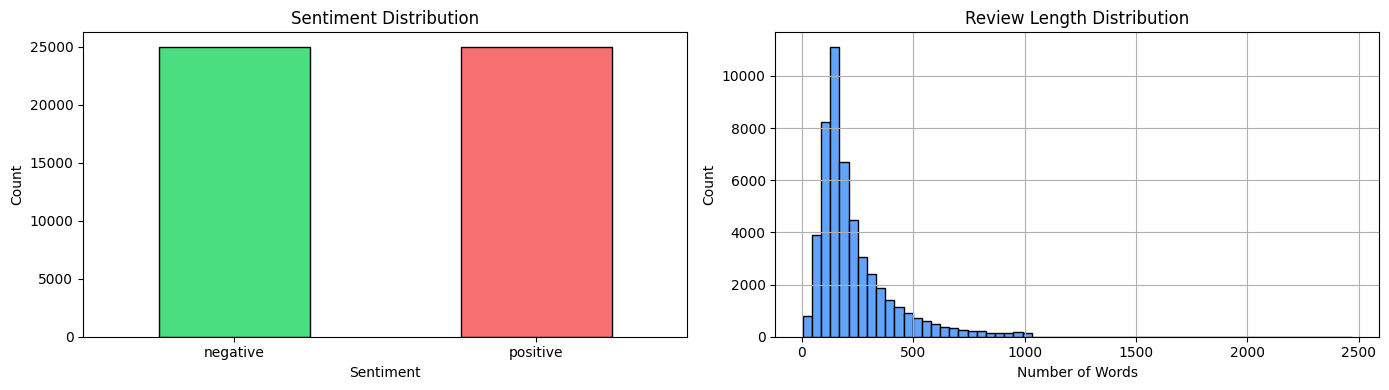

count    50000.0
mean       231.2
std        171.3
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: review_length, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1 — sentiment distribution
df["sentiment"].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["#4ade80", "#f87171"], edgecolor="black"
)
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# 2 — review length distribution
df["review_length"] = df["review"].apply(lambda x: len(str(x).split()))
df["review_length"].hist(bins=60, ax=axes[1], color="#60a5fa", edgecolor="black")
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("outputs/figures/eda.png", dpi=150)
plt.show()
print(df["review_length"].describe().round(1))

In [7]:
STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)        # strip HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)    # keep letters only
    text = re.sub(r"\s+", " ", text).strip() # collapse spaces
    tokens = [
        LEMMATIZER.lemmatize(w)
        for w in text.split()
        if w not in STOP_WORDS and len(w) > 2
    ]
    return " ".join(tokens)

def encode_label(sentiment: str) -> int:
    return 1 if str(sentiment).strip().lower() == "positive" else 0

# Apply
print("Cleaning text — this takes ~1 min ...")
df["clean_review"] = df["review"].apply(clean_text)
df["label"]        = df["sentiment"].apply(encode_label)

os.makedirs("data/processed", exist_ok=True)
df[["clean_review", "label"]].to_csv("data/processed/clean_data.csv", index=False)

df[["review", "clean_review", "label"]].head(3)

Cleaning text — this takes ~1 min ...


,review,clean_review,label
0,"Ms Aparna Sen, the maker of Mr & Mrs Iyer, dir...",aparna sen maker mr iyer directs movie young g...,0
1,"I have seen this film only once, on TV, and it...",seen film repeated strange consider rubbish re...,0
2,I was only fourteen when I first saw the Alien...,fourteen first saw alien movie immediately cam...,1


In [8]:
df_clean = pd.read_csv("data/processed/clean_data.csv")

X = df_clean["clean_review"].fillna("")
y = df_clean["label"]

# 80/20 split — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# TF-IDF
tfidf = TfidfVectorizer(
    max_features = 10_000,
    ngram_range  = (1, 2),   # unigrams + bigrams
    sublinear_tf = True,     # log-scale TF
    min_df       = 3,
)
X_train_tfidf = tfidf.fit_transform(X_train)   # fit on train ONLY
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Train matrix: {X_train_tfidf.shape}")

os.makedirs("models", exist_ok=True)
joblib.dump(tfidf, "models/vectorizer.pkl")


Train: 40,000  |  Test: 10,000
Vocabulary size: 10,000
Train matrix: (40000, 10000)


['models/vectorizer.pkl']

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs"),
    "Naive Bayes":         MultinomialNB(alpha=0.1),
}

results = {}
for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_tfidf))
    results[name] = (clf, acc)
    print(f"{name:<25} → Accuracy: {acc:.4f}")

best_name, (best_model, best_acc) = max(results.items(), key=lambda x: x[1][1])
print(f"\nBest_model: {best_name}  ({best_acc:.4f})")

joblib.dump(best_model, "models/model.pkl")

Logistic Regression       → Accuracy: 0.8965
Naive Bayes               → Accuracy: 0.8697

Best_model: Logistic Regression  (0.8965)


['models/model.pkl']

In [10]:
y_pred = best_model.predict(X_test_tfidf)
acc    = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred,
                               target_names=["Negative", "Positive"])

print(f"Accuracy: {acc:.4f}\n")
print(report)

# Save report
os.makedirs("outputs/reports", exist_ok=True)
with open("outputs/reports/classification_report.txt", "w") as f:
    f.write(f"Best model: {best_name}\nAccuracy: {acc:.4f}\n\n{report}")

Accuracy: 0.8965

              precision    recall  f1-score   support

    Negative       0.89      0.90      0.90      5000
    Positive       0.90      0.89      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



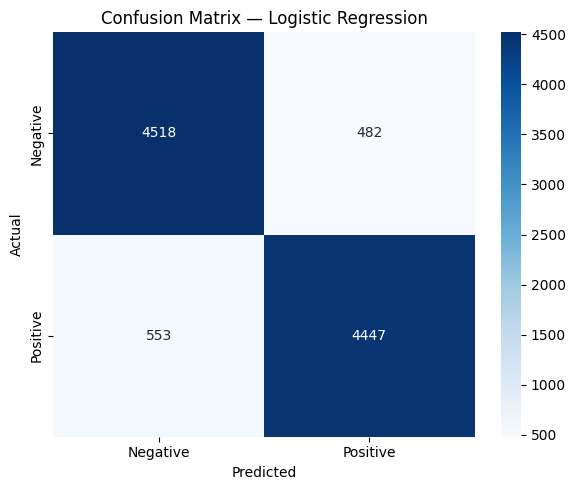

In [11]:
# Confusion matrix
os.makedirs("outputs/figures", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix.png", dpi=150)
plt.show()


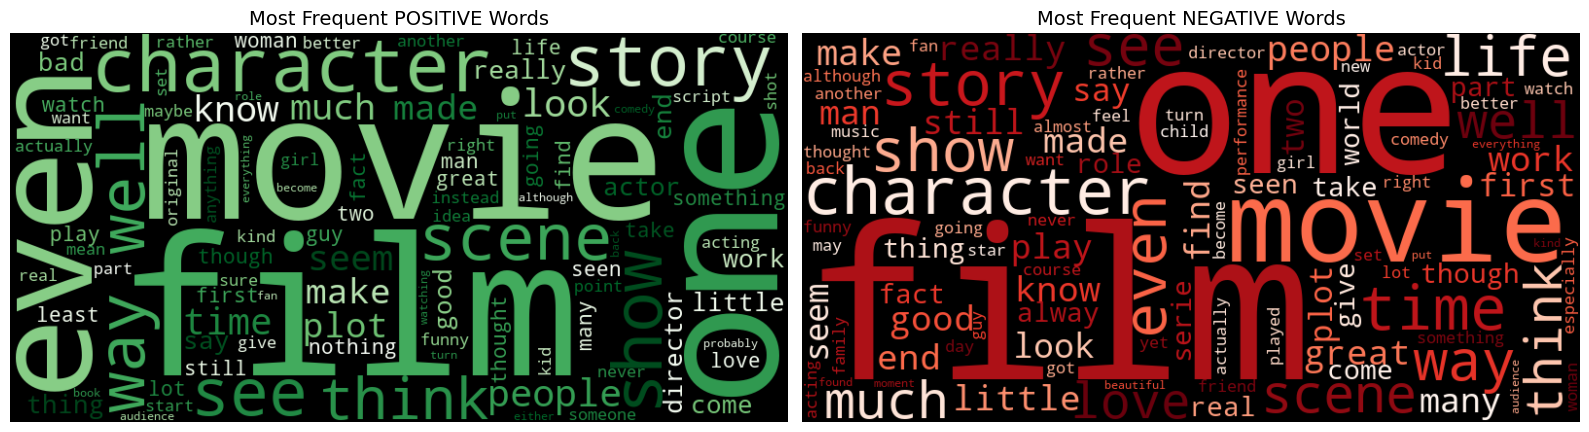

In [12]:
# Word Clouds
pos_text = " ".join(df[df["sentiment"] == "positive"]["clean_review"].dropna())
neg_text = " ".join(df[df["sentiment"] == "negative"]["clean_review"].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, text, title, cmap in zip(
    axes,
    [pos_text, neg_text],
    ["Most Frequent POSITIVE Words", "Most Frequent NEGATIVE Words"],
    ["Greens", "Reds"],
):
    wc = WordCloud(width=800, height=400,
                   background_color="black",
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/figures/wordclouds.png", dpi=150)
plt.show()


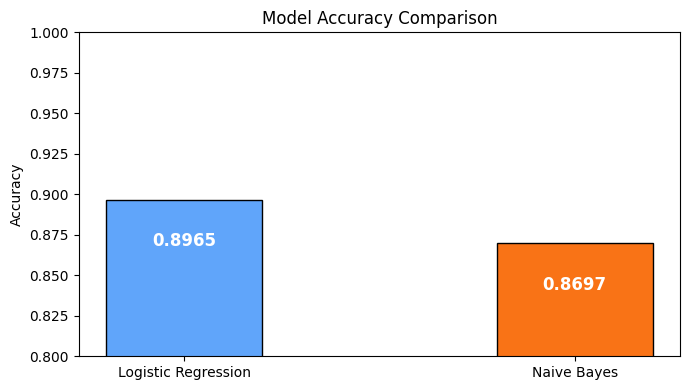

In [13]:
# Model comparison bar chart
model_names = list(results.keys())
accuracies  = [v[1] for v in results.values()]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, accuracies,
               color=["#60a5fa", "#f97316"], edgecolor="black", width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.02,
             f"{acc:.4f}", ha="center", va="top",
             fontsize=12, fontweight="bold", color="white")
plt.ylim(0.8, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("outputs/figures/model_comparison.png", dpi=150)
plt.show()


In [14]:
# Predict on a custom sentence
def predict_sentiment(text: str):
    cleaned = clean_text(text)
    vec     = tfidf.transform([cleaned])
    pred    = best_model.predict(vec)[0]
    prob    = best_model.predict_proba(vec)[0].max()
    label   = " Positive" if pred == 1 else "Negative"
    print(f"{label}  (confidence: {prob:.2%})  — '{text}'")

predict_sentiment("This movie was absolutely fantastic and brilliant!")
predict_sentiment("Terrible film, complete waste of time and money.")
predict_sentiment("It was okay, nothing special but not awful either.")

Negative  (confidence: 94.91%)  — 'This movie was absolutely fantastic and brilliant!'
 Positive  (confidence: 99.85%)  — 'Terrible film, complete waste of time and money.'
 Positive  (confidence: 99.89%)  — 'It was okay, nothing special but not awful either.'
